In [18]:
import sys
import pandas as pd
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.fftpack import dct
from scipy.signal import get_window
from IPython.display import HTML

In [28]:
def sa(numpyArray):
    return HTML(f"""
        <div style="max-height:300px; overflow-y:auto;">
        {pd.DataFrame(numpyArray).to_html()}
        </div>
        """)

In [2]:
def framesignal(x, frame_len, hop):
    N = frame_len
    L = len(x)
    num_frames = 1 + (L - N) // hop if L >= N else 1
    frames = np.zeros((num_frames, N))
    for i in range(num_frames):
        start = i * hop
        frames[i] = x[start:start+N]
    
    window = 0.5 * (1 - np.cos(2*np.pi*np.arange(N)/(N-1)))
    frames *= window
    return frames


In [3]:
def power_spectrum(frames, nfft):
    # frames: (F, N)
    X = np.fft.rfft(frames, n=nfft, axis=1)
    P = np.abs(X)**2
    return P  # shape (F, nfft//2+1)


In [4]:
def linear_filterbank(n_filters, nfft, fs):
    freqs = np.linspace(0, fs/2, nfft//2 + 1)
    # center freqs linearly
    centers = np.linspace(0, fs/2, n_filters + 2)  # include 0 and fs/2
    H = np.zeros((n_filters, len(freqs)))
    for m in range(n_filters):
        f_l, f_c, f_r = centers[m], centers[m+1], centers[m+2]
        # rising slope
        left = (freqs >= f_l) & (freqs <= f_c)
        H[m, left] = (freqs[left] - f_l) / (f_c - f_l + 1e-12)
        # falling slope
        right = (freqs >= f_c) & (freqs <= f_r)
        H[m, right] = (f_r - freqs[right]) / (f_r - f_c + 1e-12)
    return H, centers[1:-1]


In [5]:
def dct_type2(x):
    # simple DCT-II via explicit matrix (small M typical)
    N = x.shape[-1]
    n = np.arange(N)
    k = n.reshape((N,1))
    D = np.cos(np.pi * (2*n+1)[:,None] * k / (2*N))
    return D.dot(x)

def lfcc_from_power(P_frames, H, n_ceps):
    # P_frames: (F, K), H: (M, K)
    E = np.dot(P_frames, H.T)  # (F, M)
    E = np.maximum(E, 1e-12)
    logE = np.log(E)
    # compute DCT per frame
    ceps = np.array([dct_type2(logE[f])[:n_ceps] for f in range(logE.shape[0])])
    return ceps  # (F, n_ceps)


In [6]:
def smooth_spectrum(S, win_len=5):
    # simple moving average smoothing on magnitude spectrum (1D)
    kernel = np.ones(win_len)/win_len
    return np.convolve(S, kernel, mode='same')

def mgd_frame(x_frame, nfft=2048, gamma=0.4, alpha=0.4, smooth_win=5):
    N = len(x_frame)
    # zero-pad to nfft
    X = np.fft.fft(x_frame, n=nfft)
    n = np.arange(N)
    Y = np.fft.fft(x_frame * n, n=nfft)
    # numerator (real-part inner product)
    num = (X.real * Y.real + X.imag * Y.imag)
    # smooth magnitude spectrum
    S = np.abs(X)
    S_smooth = smooth_spectrum(S, win_len=smooth_win)
    denom = np.maximum(S_smooth**(2*gamma), 1e-12)
    tau = num / denom
    mgd = np.sign(tau) * (np.abs(tau)**alpha)
    return mgd[:nfft//2+1]  # return positive freqs

def mgdf_features(frames, nfft=2048, gamma=0.4, alpha=0.4, smooth_win=5, H=None, n_ceps=16):
    # frames: (F, N). compute mgd spectrum per frame, optionally apply filterbank H then DCT
    F = frames.shape[0]
    K = nfft//2+1
    mgd_spec = np.zeros((F, K))
    for i in range(F):
        mgd_spec[i] = mgd_frame(frames[i], nfft=nfft, gamma=gamma, alpha=alpha, smooth_win=smooth_win)
    if H is not None:
        # apply same linear filterbank H (or mel) then log + DCT
        E = np.dot(mgd_spec, H.T)  # (F, M)
        E = np.maximum(E, 1e-12)
        logE = np.log(np.abs(E))
        ceps = np.array([dct_type2(logE[f])[:n_ceps] for f in range(F)])
        return ceps
    else:
        return mgd_spec  # raw MGDF spectrum per frame


In [102]:
fs = 2**14
nfft = int(fs / 21.53) # ~21.53 Hz for Fast Fourrier Transform
t = np.linspace(0, 1.0, fs, endpoint=False)
# exemplo: fala-like = soma de senos (formantes) + ruído
x = 0.6*np.sin(2*np.pi*220*t) + 0.3*np.sin(2*np.pi*880*t) + 0.05*np.random.randn(len(t))

In [103]:
print("Nfft for 21,53 Hz of bin size {}".format(nfft))

Nfft for 21,53 Hz of bin size 760


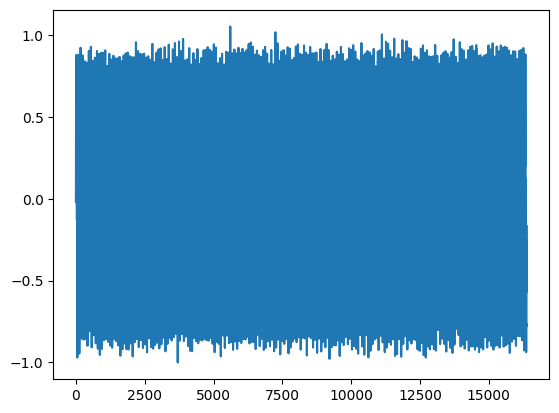

In [104]:
plt.plot(x)

In [105]:
frame_len = int(0.025*fs)
frame_len

409

In [106]:
hop = int(0.010*fs)
hop

163

In [108]:
frames = framesignal(x, frame_len, hop)  # (F, N)
sa(frames)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408
0,-0.0,8.478521e-06,9.099021e-05,0.000207,0.000389,8.573794e-04,0.001071,0.001506,0.001692,0.002005,0.002196,0.002711,0.003238,0.002143,0.002172,0.003697,0.005363,0.006812,0.010027,0.013891,0.018280,0.021731,0.024976,0.023296,0.028141,0.029641,0.026902,0.023391,0.020185,0.015414,0.005204,0.006305,-0.004898,-0.000582,-0.004745,-0.008143,-0.009906,-0.006334,0.001578,0.008141,0.000965,0.008946,0.000514,0.009278,-0.008470,-0.026112,-0.042085,-0.051724,-0.084204,-0.100180,-0.117334,-0.114094,-0.128170,-0.152821,-0.122732,-0.114148,-0.097713,-0.074007,-0.080715,-0.077173,-0.061214,-0.054164,-0.056595,-0.061894,-0.060455,-0.108762,-0.113037,-0.117839,-0.148485,-0.141029,-0.126373,-0.127309,-0.103211,-0.048982,-0.018845,0.017658,0.079092,0.117926,0.154941,0.127987,0.161123,0.210793,0.203812,0.158658,0.146990,0.103344,0.132670,0.120468,0.100843,0.130421,0.135375,0.159860,0.220907,0.254517,0.317275,0.386596,0.394486,0.405304,0.397306,0.386300,0.386917,0.289493,0.227136,0.180874,0.078951,0.051373,0.022553,-0.065509,-0.060254,-0.113563,-0.017635,-0.076986,0.029410,-0.015671,0.033327,0.050572,0.016064,-0.042148,-0.029934,-0.048912,-0.180017,-0.271819,-0.374877,-0.458347,-0.496882,-0.636954,-0.577797,-0.607351,-0.578148,-0.526257,-0.472612,-0.376051,-0.294097,-0.264910,-0.245874,-0.201093,-0.215533,-0.254913,-0.179702,-0.253876,-0.376568,-0.361636,-0.404060,-0.397499,-0.413033,-0.313659,-0.356515,-0.180509,-0.121931,0.024249,0.049080,0.260760,0.323268,0.427610,0.568048,0.520335,0.467925,0.503347,0.320440,0.329993,0.345089,0.184024,0.199250,0.230866,0.296143,0.333185,0.311764,0.525602,0.608749,0.695408,0.860343,0.718201,0.841186,0.797249,0.749944,0.584995,0.565842,0.458756,0.258349,0.228825,0.024498,-0.015366,-0.056944,-0.074579,-0.131211,-0.016011,0.008765,-0.019811,0.020651,0.118509,0.070530,0.062072,0.035804,-0.107203,-0.245525,-0.417868,-0.466742,-0.595799,-0.740279,-0.758870,-0.786354,-0.835335,-0.853814,-0.814045,-0.684333,-0.626355,-0.458282,-0.329337,-0.315795,-0.224487,-0.201836,-0.313159,-0.270333,-0.308450,-0.454803,-0.456798,-0.585258,-0.544246,-0.516104,-0.527259,-0.483861,-0.296780,-0.317531,-0.068452,0.033519,0.245631,0.353556,0.397505,0.508586,0.572313,0.549992,0.466157,0.410807,0.334666,0.310216,0.332778,0.194425,0.271052,0.264295,0.284429,0.377233,0.432727,0.462194,0.564444,0.703467,0.774656,0.786470,0.723824,0.738429,0.680067,0.506270,0.437062,0.313340,0.191488,0.109360,-0.034742,-0.071776,-0.093921,-0.038975,-0.149866,-0.034

In [112]:
P = power_spectrum(frames, nfft)  # (F, K)
sa(P)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380
0,0.006416,0.031847,0.122335,0.071612,0.559122,0.902752,2.957432,22.987165,520.746775,2185.191679,3698.644395,2921.444504,1008.070295,98.772929,0.279477,1.959289,0.788290,0.336075,0.126863,0.689141,0.911734,0.755382,0.459142,0.242335,0.170942,0.131713,0.111459,0.256359,0.944900,1.553742,0.980230,0.307387,0.336503,0.470134,0.475685,0.060262,0.981283,0.499314,20.953131,242.780757,725.433648,939.327323,570.521210,142.131531,7.161065,0.684632,0.240001,0.005507,0.045048,0.155568,0.068227,0.016699,0.022873,0.065072,0.382599,0.862076,0.992721,0.718646,0.327233,0.081982,0.080740,0.160746,0.176681,0.291384,0.498680,0.521008,0.358806,0.218354,0.139313,0.147368,0.224340,0.179077,0.078346,0.060339,0.090476,0.138476,0.192571,0.318449,0.597249,0.839989,0.715314,0.374091,0.176165,0.174036,0.434496,0.764516,0.718509,0.353936,0.058551,0.012593,0.107765,0.125822,0.050711,0.085391,0.206571,0.172504,0.097268,0.237213,0.464704,0.628157,0.701385,0.675462,0.673571,0.641001,0.414495,0.115855,0.081425,0.275049,0.293254,0.161900,0.138985,0.250084,0.339193,0.310809,0.223355,0.066400,0.033944,0.329087,0.446095,0.132971,0.028649,0.389112,0.688636,0.430590,0.028261,0.112955,0.237719,0.085074,0.009235,0.019351,0.010105,0.010001,0.053669,0.150647,0.260785,0.279249,0.153279,0.103974,0.227890,0.385332,0.566555,0.692190,0.581772,0.323198,0.113734,0.018507,0.144589,0.349975,0.244979,0.058623,0.175575,0.314083,0.291786,0.249797,0.175611,0.048809,0.018313,0.259442,0.544882,0.505474,0.302726,0.137787,0.087372,0.300122,0.419839,0.165180,0.029601,0.283383,0.395269,0.240600,0.308149,0.473272,0.617636,0.950511,0.939137,0.347515,0.103768,0.294397,0.240761,0.230323,0.416232,0.339278,0.073909,0.070742,0.410280,0.788714,0.943011,0.830168,0.527748,0.228536,0.125184,0.148037,0.164573,0.193641,0.207161,0.154476,0.045582,0.007468,0.128193,0.198696,0.175702,0.116996,0.006123,0.096146,0.292767,0.242702,0.081293,0.028786,0.102737,0.327833,0.607623,0.602120,0.248861,0.029543,0.127129,0.176968,0.157682,0.213488,0.204445,0.161199,0.148666,0.168275,0.256477,0.257799,0.148511,0.116305,0.137940,0.137496,0.112560,0.037176,0.005828,0.042546,0.051359,0.202033,0.837080,1.785807,2.156606,1.411413,0.333140,0.039389,0.600986,1.312013,1.381113,0.732092,0.211440,0.297626,0.599979,0.724019,0.651496,0.488642,0.358530,0.279060,0.136064,0.007661,0.059720,0.191334,0.199888,0.111776,0.093695,0.227716,0.432691,0.500178,0.418479,0.248517,0.080785,0.218330,0.481023,0.382002,0.117003,0.064830,0.283688,0.800407,1.284132,1.244671,0.817386,0.430683,0.276304,0.332763,0.317465,0.073410,0.080668,0.599774,0.892648,0.586818,

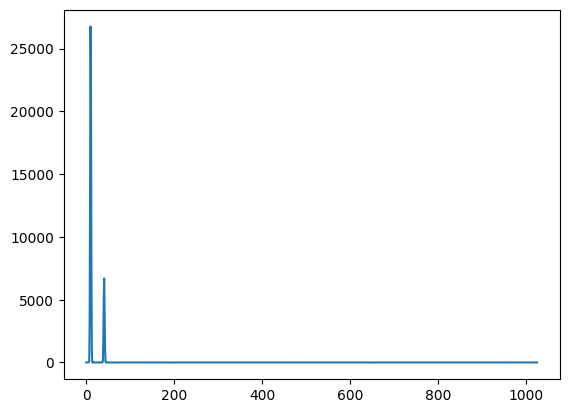

In [90]:
plt.plot(P[97])

In [72]:
H, centers = linear_filterbank(n_filters=32, nfft=nfft, fs=fs)
H[0].size

24

In [15]:
lfcc = lfcc_from_power(P, H, n_ceps=16)  # (F, 16)
mgd_ceps = mgdf_features(frames, nfft=nfft, gamma=0.4, alpha=0.4, smooth_win=5, H=H, n_ceps=16)
# concat features per frame
feats = np.concatenate([lfcc, mgd_ceps], axis=1)  # (F, 32)
print("frames:", frames.shape, "LFCC:", lfcc.shape, "MGD-cep:", mgd_ceps.shape, "concat:", feats.shape)


ValueError: shapes (32,1) and (32,) not aligned: 1 (dim 1) != 32 (dim 0)